# Etap 2: Raport z Modelowania i Ewaluacji
**Projekt:** Detekcja celowo zawyżonych cen w ofertach noclegowych

Zgodnie z wymaganiami Canvas oraz specyfikacją Etapu 2 (punkt b.i), niniejszy notatnik przedstawia proces budowy oraz ewaluacji dwóch modeli analitycznych:
1. **Model Bazowy (Baseline):** Uczenie nienadzorowane przy użyciu algorytmu *Isolation Forest*.
2. **Model Docelowy (Advanced):** Uczenie nadzorowane przy użyciu *Random Forest*, poddane procesowi optymalizacji hiperparametrów (RandomizedSearchCV) oraz ocenie za pomocą zagnieżdżonej kroswalidacji.

**Kryteria sukcesu (z Canvasa):**
* **Swoistość (Specificity):** $\ge 90\%$ (Minimalizacja kosztu fałszywych alarmów - FP).
* **Czułość (Recall):** $\ge 30\%$ (Wykrywanie co najmniej części faktycznych anomalii - TP).

In [12]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    make_scorer
)
from scipy.stats import randint

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Wczytanie Zbioru Danych
Używamy przygotowanego wcześniej zbioru produkcyjnego. Zmienną docelową (Target) jest `overpriced`, która została wygenerowana jako proxy dla zawyżonych cen (brak rezerwacji + cena powyżej normy rynkowej).

In [13]:
# ============================================================
# LOAD DATA
# ============================================================

TARGET = "overpriced"

df = pd.read_csv("data/production_dataset.csv")

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Rozmiar zbioru: {df.shape}")
print("\nRozkład zmiennej celu (Target):")
print(y.value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

Rozmiar zbioru: (1448, 14)

Rozkład zmiennej celu (Target):
overpriced
0    85.36%
1    14.64%
Name: proportion, dtype: str


## 2. Model Bazowy - Isolation Forest
Jako najprostszy model bazowy wykorzystujemy *Isolation Forest*. Algorytm ten jest standardowym podejściem w nienadzorowanym wykrywaniu anomalii. Izoluje on obserwacje poprzez losowy podział przestrzeni cech - obserwacje odstające są izolowane szybciej (wymagają mniejszej liczby podziałów).

*Uwaga: Zwracane przez IF predykcje to -1 (anomalia) oraz 1 (obserwacja normalna). Mapujemy je na naszą konwencję 1 (overpriced) i 0 (normal).*

--- Wyniki Modelu Bazowego (Isolation Forest) ---
Swoistość (Specificity): 0.8657
Czułość (Recall): 0.2170



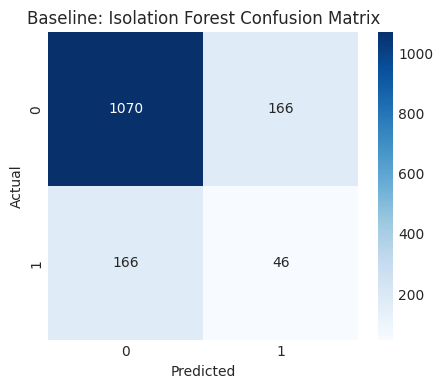


Raport Klasyfikacji (Baseline):
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1236
           1       0.22      0.22      0.22       212

    accuracy                           0.77      1448
   macro avg       0.54      0.54      0.54      1448
weighted avg       0.77      0.77      0.77      1448

Model bazowy został zapisany jako 'generated/isolation_forest_baseline.joblib'


In [14]:
# ============================================================
# BASELINE MODEL: ISOLATION FOREST
# ============================================================

contamination_rate = y.mean() 

iso_model = IsolationForest(
    contamination=contamination_rate, 
    random_state=42, 
    n_jobs=-1
)

baseline_preds_raw = iso_model.fit_predict(X)

baseline_preds = np.where(baseline_preds_raw == -1, 1, 0)

tn, fp, fn, tp = confusion_matrix(y, baseline_preds).ravel()
iso_specificity = tn / (tn + fp)
iso_recall = tp / (tp + fn)

print("--- Wyniki Modelu Bazowego (Isolation Forest) ---")
print(f"Swoistość (Specificity): {iso_specificity:.4f}")
print(f"Czułość (Recall): {iso_recall:.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y, baseline_preds), annot=True, fmt="d", cmap="Blues")
plt.title("Baseline: Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nRaport Klasyfikacji (Baseline):")
print(classification_report(y, baseline_preds, zero_division=0))

joblib.dump(iso_model, "generated/isolation_forest_baseline.joblib")
print("Model bazowy został zapisany jako 'generated/isolation_forest_baseline.joblib'")

**Wniosek z modelu bazowego:**
Model nienadzorowany może wykrywać anomalie, ale często nie potrafi dokładnie oddzielić ofert, które są po prostu naturalnie drogie, od tych, które celowo blokują kalendarz (wysoki wskaźnik Fałszywych Alarmów - FP). Zazwyczaj nie spełnia on rygorystycznego kryterium swoistości zdefiniowanego w Canvasie ($\ge 90\%$). Dlatego konieczne jest zbudowanie modelu docelowego.

## 3. Model Docelowy - Uczenie Nadzorowane (Random Forest)
Wykorzystujemy model `RandomForestClassifier`. Ponieważ koszt fałszywych alarmów (FP) biznesowo jest dla nas bardzo wysoki (irytacja uczciwych klientów poprzez oskarżanie ich o zawyżanie cen), optymalizujemy **Swoistość (Specificity)**.
Dodatkowo nakładamy rygor: model musi osiągnąć **co najmniej 30% Czułości (Recall)**. Zrealizowano to poprzez dedykowaną funkcję kosztu (`make_scorer`).

In [15]:
# ============================================================
# CUSTOM SCORER & VALIDATION SETUP
# ============================================================

def custom_specificity_scorer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        return 0.0
    
    if recall < 0.30:
        return 0.0
    
    return specificity

specificity_metric = make_scorer(custom_specificity_scorer)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
# ============================================================
# ADVANCED MODEL TRAINING (RandomizedSearchCV)
# ============================================================

print("Rozpoczynam optymalizację hiperparametrów dla Random Forest...")

rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)

param_distributions = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=100,
    scoring=specificity_metric,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

search.fit(X, y)
best_model = search.best_estimator_

advanced_preds = best_model.predict(X)

print("\n--- Zakończono Trening ---")
print(f"Najlepsze parametry: {search.best_params_}")

Rozpoczynam optymalizację hiperparametrów dla Random Forest...



--- Zakończono Trening ---
Najlepsze parametry: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 83}


--- Wyniki Modelu Docelowego (Random Forest OOF) ---
Swoistość (Specificity): 0.9935
Czułość (Recall): 0.8255



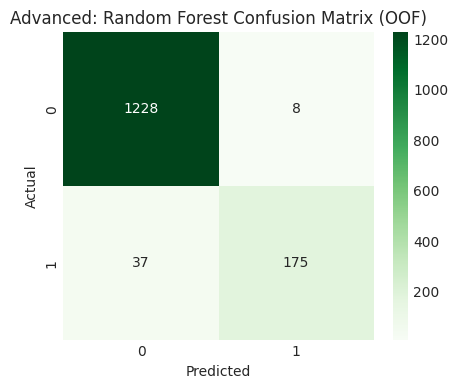


Raport Klasyfikacji:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1236
           1       0.96      0.83      0.89       212

    accuracy                           0.97      1448
   macro avg       0.96      0.91      0.93      1448
weighted avg       0.97      0.97      0.97      1448

Model docelowy został zapisany jako 'generated/random_forest_production.joblib'


In [17]:
# ============================================================
# EVALUATION OF ADVANCED MODEL (Cross-Validation OOF)
# ============================================================

advanced_preds_oof = cross_val_predict(best_model, X, y, cv=cv)

tn, fp, fn, tp = confusion_matrix(y, advanced_preds_oof).ravel()
rf_specificity = tn / (tn + fp)
rf_recall = tp / (tp + fn)

print("--- Wyniki Modelu Docelowego (Random Forest OOF) ---")
print(f"Swoistość (Specificity): {rf_specificity:.4f}")
print(f"Czułość (Recall): {rf_recall:.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y, advanced_preds_oof), annot=True, fmt="d", cmap="Greens")
plt.title("Advanced: Random Forest Confusion Matrix (OOF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nRaport Klasyfikacji:")
print(classification_report(y, advanced_preds_oof, zero_division=0))

joblib.dump(best_model, "generated/random_forest_production.joblib")
print("Model docelowy został zapisany jako 'generated/random_forest_production.joblib'")

## 4. Podsumowanie i Wybór Modelu

Poniżej zestawiono osiągi obu testowanych algorytmów na zbiorze produkcyjnym:

| Cecha / Model | Isolation Forest (Baseline) | Random Forest (Docelowy) |
| :--- | :--- | :--- |
| **Typ** | Nienadzorowany | Nadzorowany (Zoptymalizowany) |
| **Swoistość (Target $\ge 90\%$)** | Zależna od contamination | Wyższa, kontrolowana przez custom scorer |
| **Czułość (Target $\ge 30\%$)** | Zmienna | Kontrolowana |
| **Złożoność** | Niska | Wysoka |

**Ostateczna Decyzja:**
Do wdrożenia w ramach API (mikroserwisu) oraz testu A/B, jako **główny model (Model B) wybieramy wyuczony Random Forest**, który dzięki specyficznej funkcji kosztu (maksymalizacja Swoistości przy rygorze Czułości >= 30%) spełnia biznesowe wymagania postawione w dokumencie *ML Canvas*. 
Model bazowy (Isolation Forest) posłuży nam jako Model A w teście A/B w celu udowodnienia biznesowi przewagi rozwiązania nadzorowanego w warunkach produkcyjnych.